In [ ]:
# Run this once — installs fairlearn
!pip install fairlearn

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import (demographic_parity_difference,
                                   equalized_odds_difference,
                                   MetricFrame)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from xgboost import XGBClassifier

print("All imports OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 49.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
All imports OK


In [11]:

BASE = "/content/drive/MyDrive/faircredit_work"

X_train = pd.read_csv(f"{BASE}/X_train.csv")
X_test  = pd.read_csv(f"{BASE}/X_test.csv")
y_train = pd.read_csv(f"{BASE}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{BASE}/y_test.csv").squeeze()
model   = joblib.load(f"{BASE}/xgb_baseline.pkl")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Columns:", list(X_train.columns))
print("Model loaded ✓")

X_train: (96658, 11)
X_test : (24165, 11)
Columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalPastDue']
Model loaded ✓


In [12]:
# ── 1. AGE GROUPS ──────────────────────────────────────────
# Young people may get unfairly rejected due to less credit history
def age_group(age):
    if age < 35:   return "Young"
    elif age <= 60: return "Middle"
    else:           return "Senior"

# ── 2. INCOME GROUPS ───────────────────────────────────────
# Low income people may be rejected even with good payment history
def income_group(income):
    if income < 3000:   return "Low"
    elif income <= 7000: return "Middle"
    else:                 return "High"

# ── 3. DEPENDENTS GROUPS ───────────────────────────────────
# People with large families may be unfairly penalized
def dependents_group(dep):
    if dep == 0:   return "None"
    elif dep <= 2: return "Small"
    else:          return "Large"

# Apply to both train and test sets
age_groups_test       = X_test["age"].apply(age_group)
age_groups_train      = X_train["age"].apply(age_group)

income_groups_test    = X_test["MonthlyIncome"].apply(income_group)
income_groups_train   = X_train["MonthlyIncome"].apply(income_group)

dependents_groups_test  = X_test["NumberOfDependents"].apply(dependents_group)
dependents_groups_train = X_train["NumberOfDependents"].apply(dependents_group)

print("Age groups:\n",        age_groups_test.value_counts())
print("\nIncome groups:\n",    income_groups_test.value_counts())
print("\nDependents groups:\n", dependents_groups_test.value_counts())

Age groups:
 age
Middle    14025
Senior     6795
Young      3345
Name: count, dtype: int64

Income groups:
 MonthlyIncome
Middle    11927
High       7994
Low        4244
Name: count, dtype: int64

Dependents groups:
 NumberOfDependents
None     13285
Small     8409
Large     2471
Name: count, dtype: int64


In [13]:
y_pred_baseline = model.predict(X_test)

print("Baseline predictions done ✓")
print("Predicted defaults    :", (y_pred_baseline == 1).sum())
print("Predicted non-defaults:", (y_pred_baseline == 0).sum())

Baseline predictions done ✓
Predicted defaults    : 5983
Predicted non-defaults: 18182


In [14]:
def measure_bias(y_true, y_pred, sensitive_features, label):
    dpd = demographic_parity_difference(
              y_true, y_pred, sensitive_features=sensitive_features)
    eod = equalized_odds_difference(
              y_true, y_pred, sensitive_features=sensitive_features)
    mf  = MetricFrame(
              metrics={"accuracy": accuracy_score,
                       "precision": precision_score,
                       "recall": recall_score},
              y_true=y_true, y_pred=y_pred,
              sensitive_features=sensitive_features)
    print(f"\n── {label} ──")
    print(f"  Demographic Parity Difference : {dpd:.4f}")
    print(f"  Equalized Odds Difference     : {eod:.4f}")
    print(f"  Per-group breakdown:\n", mf.by_group)
    return dpd, eod

# Run for all 3 protected attributes
dpd_age_before, eod_age_before = measure_bias(
    y_test, y_pred_baseline, age_groups_test, "AGE")

dpd_inc_before, eod_inc_before = measure_bias(
    y_test, y_pred_baseline, income_groups_test, "INCOME")

dpd_dep_before, eod_dep_before = measure_bias(
    y_test, y_pred_baseline, dependents_groups_test, "DEPENDENTS")


── AGE ──
  Demographic Parity Difference : 0.3226
  Equalized Odds Difference     : 0.2798
  Per-group breakdown:
         accuracy  precision    recall
age                                  
Middle  0.771765   0.227851  0.792948
Senior  0.902134   0.161245  0.612903
Young   0.657399   0.234057  0.863049

── INCOME ──
  Demographic Parity Difference : 0.2017
  Equalized Odds Difference     : 0.1892
  Per-group breakdown:
                accuracy  precision    recall
MonthlyIncome                               
High           0.852639   0.188506  0.673973
Low            0.703817   0.224015  0.863184
Middle         0.783936   0.233941  0.802632

── DEPENDENTS ──
  Demographic Parity Difference : 0.1096
  Equalized Odds Difference     : 0.0994
  Per-group breakdown:
                     accuracy  precision    recall
NumberOfDependents                               
Large               0.729259   0.226131  0.772532
None                0.821603   0.222734  0.782338
Small               0.76

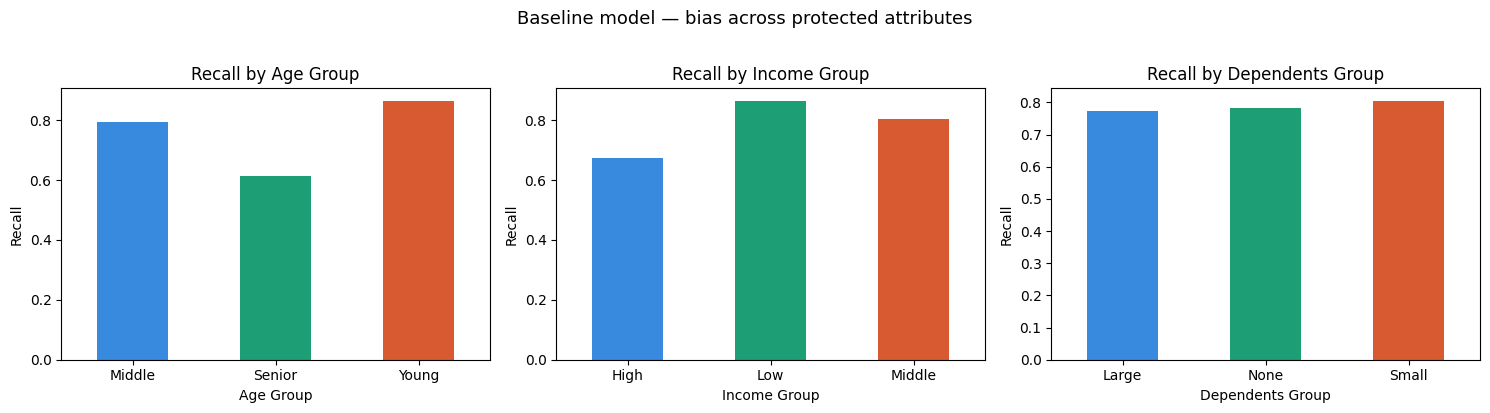

Saved fairness_by_group.png ✓


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sensitive, label, colors in zip(
    axes,
    [age_groups_test, income_groups_test, dependents_groups_test],
    ["Age Group", "Income Group", "Dependents Group"],
    [["#378ADD", "#1D9E75", "#D85A30"],
     ["#378ADD", "#1D9E75", "#D85A30"],
     ["#378ADD", "#1D9E75", "#D85A30"]]
):
    mf = MetricFrame(
        metrics={"recall": recall_score},
        y_true=y_test, y_pred=y_pred_baseline,
        sensitive_features=sensitive)
    mf.by_group["recall"].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"Recall by {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Recall")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Baseline model — bias across protected attributes",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/reports/fairness_by_group.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fairness_by_group.png ✓")

In [16]:
# We train on age groups — the strongest protected attribute
# This is normal practice: pick one for mitigation training

estimator = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

mitigator = ExponentiatedGradient(
    estimator,
    DemographicParity()
)

mitigator.fit(X_train, y_train, sensitive_features=age_groups_train)

y_pred_fair = mitigator.predict(X_test)
print("Fair model trained ✓")

Fair model trained ✓


In [17]:
print("=== BIAS AFTER MITIGATION ===")

dpd_age_after, eod_age_after = measure_bias(
    y_test, y_pred_fair, age_groups_test, "AGE")

dpd_inc_after, eod_inc_after = measure_bias(
    y_test, y_pred_fair, income_groups_test, "INCOME")

dpd_dep_after, eod_dep_after = measure_bias(
    y_test, y_pred_fair, dependents_groups_test, "DEPENDENTS")

=== BIAS AFTER MITIGATION ===

── AGE ──
  Demographic Parity Difference : 0.0167
  Equalized Odds Difference     : 0.1007
  Per-group breakdown:
         accuracy  precision    recall
age                                  
Middle  0.928057   0.641399  0.198915
Senior  0.972185   0.471698  0.134409
Young   0.889088   0.633333  0.098191

── INCOME ──
  Demographic Parity Difference : 0.0216
  Equalized Odds Difference     : 0.0971
  Per-group breakdown:
                accuracy  precision    recall
MonthlyIncome                               
High           0.955967   0.614035  0.095890
Low            0.910462   0.590164  0.179104
Middle         0.929823   0.635379  0.192982

── DEPENDENTS ──
  Demographic Parity Difference : 0.0165
  Equalized Odds Difference     : 0.0937
  Per-group breakdown:
                     accuracy  precision    recall
NumberOfDependents                               
Large               0.911777   0.605634  0.184549
None                0.942266   0.613497  0.1

In [18]:
acc_before = accuracy_score(y_test, y_pred_baseline)
f1_before  = f1_score(y_test, y_pred_baseline)
acc_after  = accuracy_score(y_test, y_pred_fair)
f1_after   = f1_score(y_test, y_pred_fair)

comparison = pd.DataFrame({
    "Metric": [
        "DPD — Age",
        "EOD — Age",
        "DPD — Income",
        "EOD — Income",
        "DPD — Dependents",
        "EOD — Dependents",
        "Overall Accuracy",
        "Overall F1-Score",
    ],
    "Before Mitigation": [
        round(dpd_age_before, 4),
        round(eod_age_before, 4),
        round(dpd_inc_before, 4),
        round(eod_inc_before, 4),
        round(dpd_dep_before, 4),
        round(eod_dep_before, 4),
        round(acc_before,     4),
        round(f1_before,      4),
    ],
    "After Mitigation": [
        round(dpd_age_after, 4),
        round(eod_age_after, 4),
        round(dpd_inc_after, 4),
        round(eod_inc_after, 4),
        round(dpd_dep_after, 4),
        round(eod_dep_after, 4),
        round(acc_after,     4),
        round(f1_after,      4),
    ]
})

print(comparison.to_string(index=False))
comparison.to_csv(f"{BASE}/reports/fairness_comparison.csv", index=False)
print("\nSaved fairness_comparison.csv ✓")

          Metric  Before Mitigation  After Mitigation
       DPD — Age             0.3226            0.0167
       EOD — Age             0.2798            0.1007
    DPD — Income             0.2017            0.0216
    EOD — Income             0.1892            0.0971
DPD — Dependents             0.1096            0.0165
EOD — Dependents             0.0994            0.0937
Overall Accuracy             0.7926            0.9351
Overall F1-Score             0.3459            0.2651

Saved fairness_comparison.csv ✓


In [19]:
# Fair model — Person 4 needs this for Streamlit
joblib.dump(mitigator, f"{BASE}/xgb_fair.pkl")
print("Saved xgb_fair.pkl ✓")

# Base estimator — Person 4 needs this for SHAP
base_model = mitigator.predictors_[0]
joblib.dump(base_model, f"{BASE}/xgb_fair_base.pkl")
print("Saved xgb_fair_base.pkl ✓")

# Fairness note for the dashboard
note = ("This model has been evaluated for bias across three protected attributes: "
        "age group, income level, and number of dependents. "
        "It was retrained using ExponentiatedGradient with a DemographicParity constraint "
        "to ensure fairer loan decisions across Young, Middle, and Senior age groups.")

with open(f"{BASE}/fairness_note.txt", "w") as f:
    f.write(note)
print("Saved fairness_note.txt ✓")

print("\nAll done! Files to push to GitHub:")
print("  models/xgb_fair.pkl")
print("  models/xgb_fair_base.pkl")
print("  models/fairness_note.txt")
print("  reports/fairness_comparison.csv")
print("  reports/fairness_by_group.png")

Saved xgb_fair.pkl ✓
Saved xgb_fair_base.pkl ✓
Saved fairness_note.txt ✓

All done! Files to push to GitHub:
  models/xgb_fair.pkl
  models/xgb_fair_base.pkl
  models/fairness_note.txt
  reports/fairness_comparison.csv
  reports/fairness_by_group.png


In [20]:
# Load back and test — confirm nothing is broken
test_model = joblib.load(f"{BASE}/xgb_fair.pkl")
test_base  = joblib.load(f"{BASE}/xgb_fair_base.pkl")

# Make a prediction with both
sample = X_test.iloc[:5]
print("Fair model predictions:", test_model.predict(sample))
print("Base model predictions:", test_base.predict(sample))
print("Both files are healthy ✓")

Fair model predictions: [0 0 0 0 0]
Base model predictions: [0 0 0 0 0]
Both files are healthy ✓
